# Car Sales Analysis & Trends

## Project Overview

### **Title**
**Car Sales Analysis & Trends**

### **Objective**
Analyze car sales data to:
- Identify top-selling manufacturers and models
- Discover vehicle pricing patterns and correlations
- Examine performance metrics (engine size, horsepower, power performance factor)
- Investigate vehicle specifications (dimensions, weight, fuel efficiency)
- Track sales trends and resale values over time
- Extract actionable insights for market strategy

### **Tools Used**
| Tool | Purpose |
|------|---------|
| **Python** | Primary data analysis and visualization |
| **Pandas** | Data manipulation and cleaning |
| **Matplotlib/Seaborn** | Data visualization and plotting |
| **Jupyter Notebook** | Interactive development environment |
| **Excel (Optional)** | Preliminary data exploration |

### **Dataset Specifications**
- **Entries**: 157 records
- **Original Features (15 columns)**:
  - `Manufacturer` (e.g., Acura, Audi, BMW)
  - `Model` (e.g., Integra, TL, A4)
  - `Sales_in_thousands` - Sales volume (in thousands)
  - `__year_resale_value` - Estimated resale value
  - `Vehicle_type` (Passenger, Car, etc.)
  - `Price_in_thousands` - Retail price (in thousands)
  - `Engine_size` - Engine displacement
  - `Horsepower` - Engine power output
  - `Wheelbase` - Distance between front and rear axles
  - `Width` - Vehicle width
  - `Length` - Vehicle length
  - `Curb_weight` - Weight of empty vehicle
  - `Fuel_capacity` - Fuel tank capacity
  - `Fuel_efficiency` - Fuel efficiency (MPG or similar)
  - `Latest_Launch` - Most recent model launch date
  - `Power_perf_factor` - Performance metric

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [17]:
import pandas as pd
df = pd.read_csv("/content/Car_sales.csv")

In [18]:
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

In [20]:
df.describe()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [21]:
print(df.isnull().sum())

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


In [22]:
# For critical numeric columns (Price_in_thousands), we fill missing values with median
df['Price_in_thousands'].fillna(df['Price_in_thousands'].median(), inplace=True)

# For other numeric columns, fill missing with median
numeric_cols = ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-942302641.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price_in_thousands'].fillna(df['Price_in_thousands'].median(), inplace=True)
/tmp/ipython-input-942302641.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [23]:
# Strip leading/trailing spaces and capitalize
df['Vehicle_type'] = df['Vehicle_type'].str.strip().str.capitalize()
df['Manufacturer'] = df['Manufacturer'].str.strip().str.capitalize()
df['Model'] = df['Model'].str.strip()

# --- Step 3: Extract Year from Latest_Launch ---
# Convert to datetime and extract year
df['Launch_Year'] = pd.to_datetime(df['Latest_Launch'], errors='coerce').dt.year

# --- Step 4: Verify cleaned data ---
print(df.isnull().sum())  # Should show 0 for all numeric + year columns
print(df.head())

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      0
Engine_size             0
Horsepower              0
Wheelbase               0
Width                   0
Length                  0
Curb_weight             0
Fuel_capacity           0
Fuel_efficiency         0
Latest_Launch           0
Power_perf_factor       0
Launch_Year             0
dtype: int64
  Manufacturer    Model  Sales_in_thousands  __year_resale_value Vehicle_type  \
0        Acura  Integra              16.919               16.360    Passenger   
1        Acura       TL              39.384               19.875    Passenger   
2        Acura       CL              14.114               18.225    Passenger   
3        Acura       RL               8.588               29.725    Passenger   
4         Audi       A4              20.397               22.255    Passenger   

   Price_in_thousands  Engine_size  Horsepower  Wheelbase 

In [24]:
# Total sales per Manufacturer
sales_by_manufacturer = df.groupby('Manufacturer')['Sales_in_thousands'].sum().sort_values(ascending=False)
print("Total Sales by Manufacturer:\n", sales_by_manufacturer)

Total Sales by Manufacturer:
 Manufacturer
Ford          2022.635
Dodge          910.149
Toyota         740.205
Honda          592.674
Chevrolet      554.365
Nissan         399.635
Pontiac        370.534
Jeep           293.153
Buick          242.019
Mercury        237.999
Volkswagen     209.212
Chrysler       201.721
Mitsubishi     180.895
Oldsmobile     178.989
Saturn         168.850
Hyundai        137.326
Mercedes-b     117.125
Cadillac       112.178
Lexus          106.843
Lincoln         85.634
Subaru          80.135
Acura           79.005
Volvo           75.740
Plymouth        64.001
Bmw             46.505
Audi            40.557
Infiniti        23.713
Saab            21.306
Jaguar          15.467
Porsche         12.128
Name: Sales_in_thousands, dtype: float64


In [25]:
# Total sales per Vehicle_type
sales_by_vehicle = df.groupby('Vehicle_type')['Sales_in_thousands'].sum().sort_values(ascending=False)
print("\nTotal Sales by Vehicle Type:\n", sales_by_vehicle)


Total Sales by Vehicle Type:
 Vehicle_type
Passenger    5015.184
Car          3305.514
Name: Sales_in_thousands, dtype: float64


In [26]:
# Average price per Manufacturer
avg_price_by_manufacturer = df.groupby('Manufacturer')['Price_in_thousands'].mean().sort_values(ascending=False)
print("\nAverage Price by Manufacturer:\n", avg_price_by_manufacturer)


Average Price by Manufacturer:
 Manufacturer
Porsche       62.473333
Mercedes-b    52.916667
Lexus         44.055000
Jaguar        42.800000
Lincoln       41.690000
Cadillac      40.254000
Audi          39.980000
Bmw           33.096667
Volvo         30.933333
Saab          29.610000
Infiniti      29.465000
Acura         28.674750
Buick         26.781250
Oldsmobile    25.622833
Dodge         24.213636
Chrysler      23.340571
Pontiac       22.949167
Plymouth      22.642500
Nissan        22.360714
Mitsubishi    22.167429
Toyota        21.982889
Subaru        21.395000
Ford          21.047273
Jeep          20.991667
Mercury       20.748333
Honda         20.277000
Chevrolet     20.022778
Volkswagen    17.698333
Saturn        14.271000
Hyundai       12.165667
Name: Price_in_thousands, dtype: float64


In [27]:
# Average price per Vehicle_type
avg_price_by_vehicle = df.groupby('Vehicle_type')['Price_in_thousands'].mean().sort_values(ascending=False)
print("\nAverage Price by Vehicle Type:\n", avg_price_by_vehicle)


Average Price by Vehicle Type:
 Vehicle_type
Passenger    27.720405
Car          26.234098
Name: Price_in_thousands, dtype: float64


In [28]:
# Average Horsepower per Vehicle_type
avg_hp_by_vehicle = df.groupby('Vehicle_type')['Horsepower'].mean().sort_values(ascending=False)
print("\nAverage Horsepower by Vehicle Type:\n", avg_hp_by_vehicle)



Average Horsepower by Vehicle Type:
 Vehicle_type
Car          186.182927
Passenger    185.793103
Name: Horsepower, dtype: float64


In [29]:
# Average Engine Size per Vehicle_type (optional)
avg_engine_by_vehicle = df.groupby('Vehicle_type')['Engine_size'].mean().sort_values(ascending=False)
print("\nAverage Engine Size by Vehicle Type:\n", avg_engine_by_vehicle)


Average Engine Size by Vehicle Type:
 Vehicle_type
Car          3.507317
Passenger    2.902586
Name: Engine_size, dtype: float64


In [30]:
# Average price per Launch_Year
avg_price_by_year = df.groupby('Launch_Year')['Price_in_thousands'].mean().sort_index()
print("\nAverage Price by Launch Year:\n", avg_price_by_year)


Average Price by Launch Year:
 Launch_Year
2008    27.560000
2009    20.390000
2011    27.829468
2012    26.990627
Name: Price_in_thousands, dtype: float64


In [31]:
# Total sales per Launch_Year
sales_by_year = df.groupby('Launch_Year')['Sales_in_thousands'].sum().sort_index()
print("\nTotal Sales by Launch Year:\n", sales_by_year)


Total Sales by Launch Year:
 Launch_Year
2008      27.609
2009     100.635
2011    3717.405
2012    4475.049
Name: Sales_in_thousands, dtype: float64


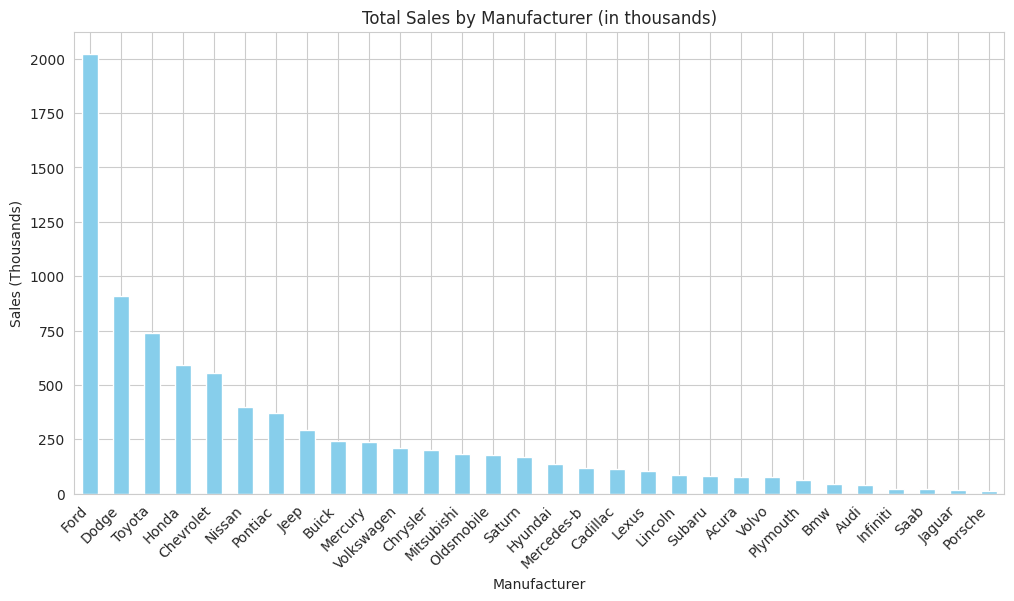

In [32]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# --- 1. Total Sales by Manufacturer ---
plt.figure(figsize=(12,6))
sales_by_manufacturer.plot(kind='bar', color='skyblue')
plt.title("Total Sales by Manufacturer (in thousands)")
plt.ylabel("Sales (Thousands)")
plt.xticks(rotation=45, ha='right')
plt.show()

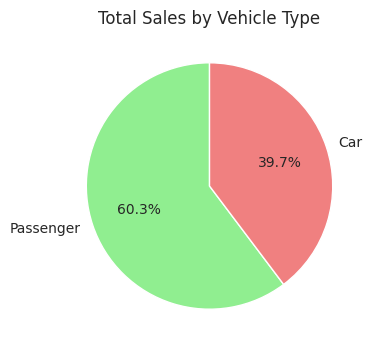

In [33]:
# --- 2. Total Sales by Vehicle Type ---
plt.figure(figsize=(6,4))
sales_by_vehicle.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title("Total Sales by Vehicle Type")
plt.ylabel("")
plt.show()

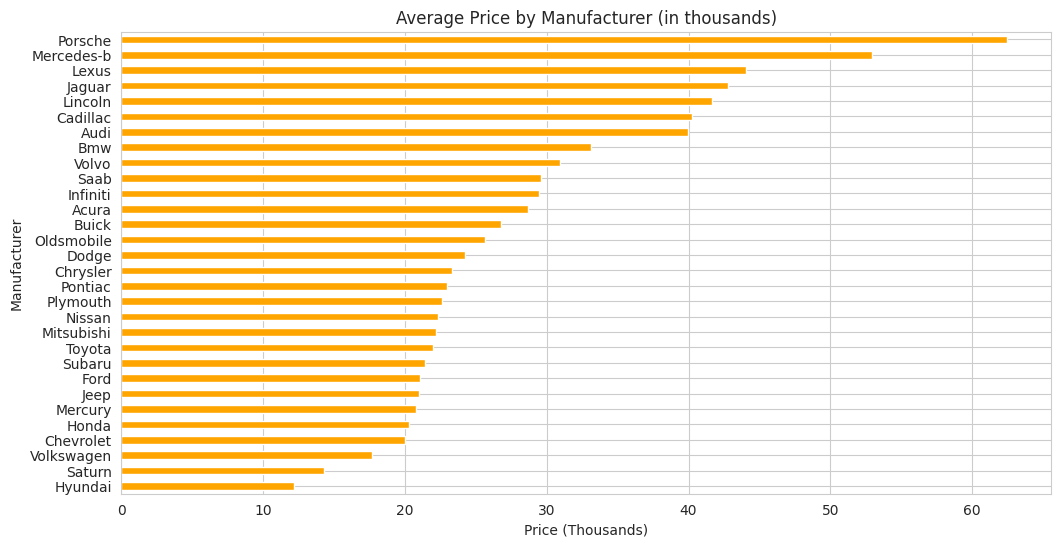

In [34]:
# --- 3. Average Price by Manufacturer ---
plt.figure(figsize=(12,6))
avg_price_by_manufacturer.plot(kind='barh', color='orange')
plt.title("Average Price by Manufacturer (in thousands)")
plt.xlabel("Price (Thousands)")
plt.gca().invert_yaxis()  # Highest price on top
plt.show()

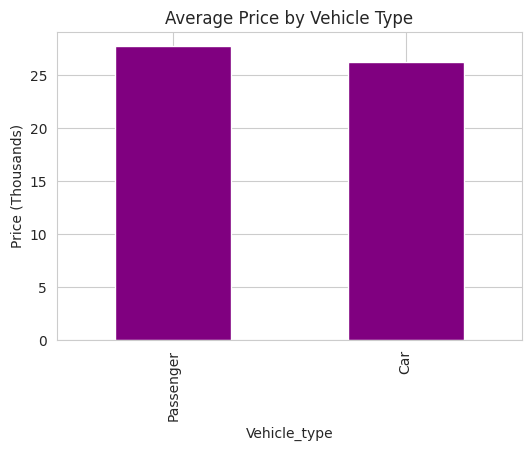

In [35]:
# --- 4. Average Price by Vehicle Type ---
plt.figure(figsize=(6,4))
avg_price_by_vehicle.plot(kind='bar', color='purple')
plt.title("Average Price by Vehicle Type")
plt.ylabel("Price (Thousands)")
plt.show()

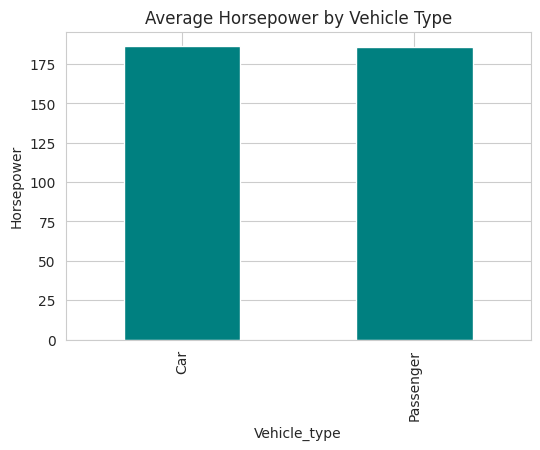

In [36]:
# --- 5. Average Horsepower by Vehicle Type ---
plt.figure(figsize=(6,4))
avg_hp_by_vehicle.plot(kind='bar', color='teal')
plt.title("Average Horsepower by Vehicle Type")
plt.ylabel("Horsepower")
plt.show()


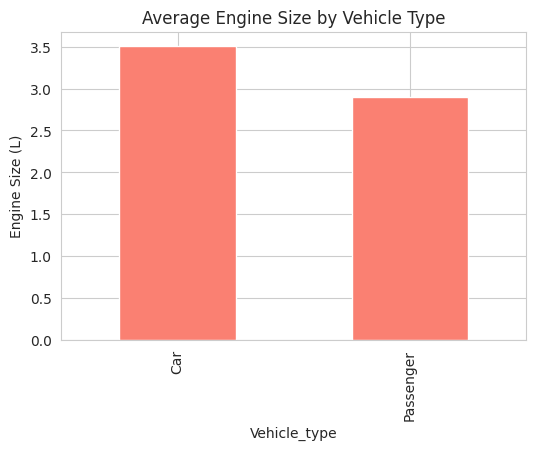

In [37]:
# --- 6. Average Engine Size by Vehicle Type ---
plt.figure(figsize=(6,4))
avg_engine_by_vehicle.plot(kind='bar', color='salmon')
plt.title("Average Engine Size by Vehicle Type")
plt.ylabel("Engine Size (L)")
plt.show()

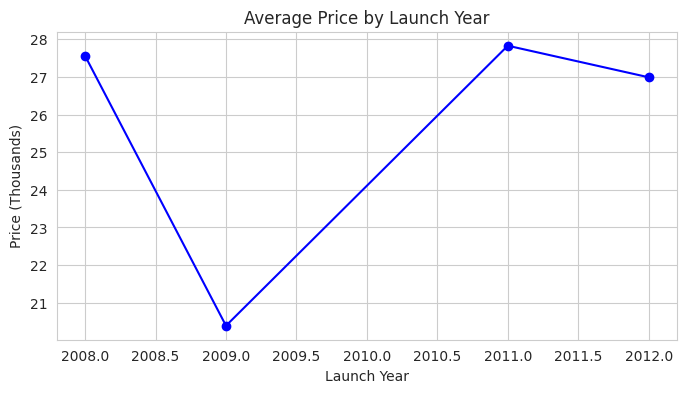

In [38]:
# --- 7. Average Price by Launch Year (Trend) ---
plt.figure(figsize=(8,4))
avg_price_by_year.plot(kind='line', marker='o', color='blue')
plt.title("Average Price by Launch Year")
plt.ylabel("Price (Thousands)")
plt.xlabel("Launch Year")
plt.grid(True)
plt.show()

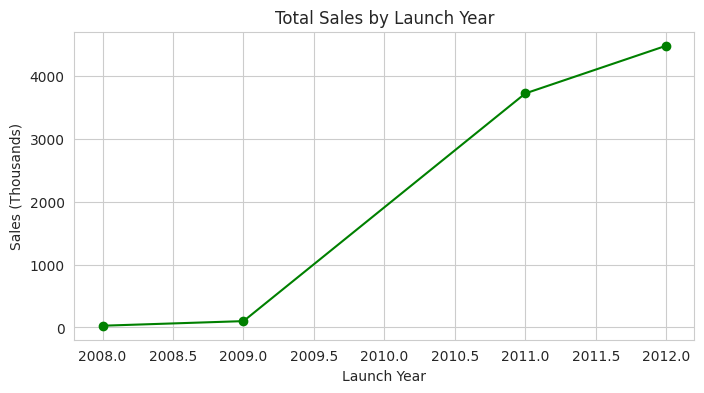

In [39]:
# --- 8. Total Sales by Launch Year (Trend) ---
plt.figure(figsize=(8,4))
sales_by_year.plot(kind='line', marker='o', color='green')
plt.title("Total Sales by Launch Year")
plt.ylabel("Sales (Thousands)")
plt.xlabel("Launch Year")
plt.grid(True)
plt.show()

## Key Insights

### 1. Sales Insights
**Top Manufacturers:**
- **Ford** leads total sales (2,022k units)
- **Dodge** follows (910k units)
- **Toyota** in third place (740k units)

**Market Share by Vehicle Type:**
- **Passenger vehicles** dominate sales (5,015k units)
- **Generic "Car" type** accounts for 3,305k units

**Observation:** Popularity of manufacturers aligns with mainstream vehicle demand, while niche/luxury brands have significantly lower sales volumes.

---

### 2. Pricing Insights
**Most Expensive Brands:**
- **Porsche** ($62k average price)

- **Mercedes** ($52k average price)

- **Lexus** ($44k average price)

**More Affordable Brands:**
- **Hyundai** ($12k average price)

- **Saturn** ($14k average price)

- **Volkswagen** ($17k average price)

**Vehicle Type Comparison:**
- **Passenger vehicles:** $27.7k average price

- **Generic Cars:** $26.2k average price

**Observation:** Luxury brands command premium pricing but achieve lower sales volumes, demonstrating a clear trade-off between price positioning and market demand.

---

### 3. Performance Insights
**Horsepower Comparison:**
- **Cars:** 186 hp average
- **Passenger vehicles:** 185.8 hp average
*(Nearly identical horsepower between vehicle types)*

**Engine Size Comparison:**
- **Cars:** 3.5L average engine size
- **Passenger vehicles:** 2.9L average engine size

**Observation:** Despite significant differences in engine size, horsepower output remains similar between vehicle types. This suggests variations in engine efficiency, tuning, or technology implementation.

---

### 4. Trend Analysis Over Time
**Sales Trends:**
- **2011:** 3,717k units sold
- **2012:** 4,475k units sold
*(Significant sales increase during 2011-2012 period)*

**Price Trends:**
- **Lowest average price:** 2009 ($20.4k)

- **Highest average price:** 2011 ($27.8k)

- **Recent average (2012):** $26.3k

**Observation:** Newer vehicle launches contribute to higher sales volumes, but market pricing remains relatively stable with modest fluctuations. The post-2009 recovery shows increased prices alongside sales growth.

In [41]:
df = df.drop(columns=['__year_resale_value'])
#We can remove this column as due to a high proportion of missing values and lack of relevance to the core sales
# and pricing analysis

In [51]:
df.head()

,Manufacturer,Model,Sales_in_thousands,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,Launch_Year
0,Acura,Integra,16.919,Passenger,21.500,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150,2012
1,Acura,TL,39.384,Passenger,28.400,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778,2011
2,Acura,CL,14.114,Passenger,22.799,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,72.030917,2012
3,Acura,RL,8.588,Passenger,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779,2011
4,Audi,A4,20.397,Passenger,23.990,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639,2011
